In [1]:
#!pip install opencv-python

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2 as cv
import os

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

/home/avishag.nevo/.local/lib/python3.6/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import json

def load_config(config_path: str) -> dict:
    """
    Loads the configuration from a JSON file.
    
    :param config_path: Path to the JSON config file.
    :return: A dictionary with configuration parameters.
    """
    with open(config_path, 'r') as f:
        config = json.load(f)
    return config

# Load configuration
config = load_config('config.json')
labels = config.get('labels', [])
print("Chosen labels:", labels)

Chosen labels: ['Giraffe', 'Horse', 'Lion', 'Zebra']


In [4]:
import os
import cv2 as cv
import numpy as np

train_dir = 'animals-detection-images-dataset/train/'
test_dir = 'animals-detection-images-dataset/test/'

# List of labels from directory names
#listdir = os.listdir(train_dir)
#labels = [label for label in listdir if label != '.DS_Store']
label_len = len(labels)
print(label_len)

# Lists to store training data
X = []
Y = []

# Load the data
for label in labels:
    folder_path = os.path.join(train_dir, label)
    for file in os.listdir(folder_path):
        img_path = os.path.join(folder_path, file)
        img = cv.imread(img_path)
        if img is not None:
            # Resize image to 224x224
            img = cv.resize(img, (224, 224))
            X.append(img)
            Y.append(labels.index(label))

# Convert lists to NumPy arrays
X = np.array(X)
Y = np.array(Y)

print("Training data dimensions:")
print("X shape:", X.shape)
print("Y shape:", Y.shape)

'''
15
Training data dimensions:
X shape: (4802, 224, 224, 3)
Y shape: (4802,)
'''



4
Training data dimensions:
X shape: (1487, 224, 224, 3)
Y shape: (1487,)


'\n15\nTraining data dimensions:\nX shape: (4802, 224, 224, 3)\nY shape: (4802,)\n'

[('Giraffe', 399), ('Horse', 501), ('Lion', 309), ('Zebra', 282)]


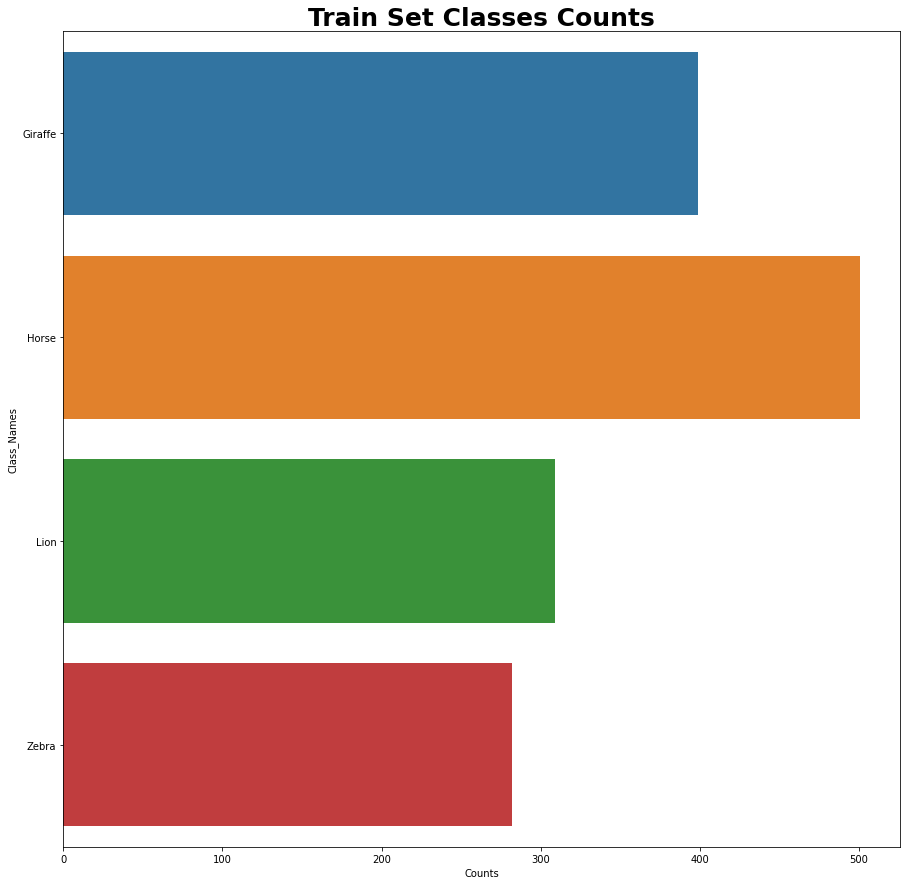

In [5]:
# A variable to store number of images in each class and class names.
counts = []

# Loop over classes
for class_name in labels :
    class_path = os.path.join(train_dir, class_name)
    count = len(os.listdir(class_path))
    counts.append((class_name, count))
print(counts)
# Convert variable to DataFrame
counts = pd.DataFrame(counts, columns=['Class_Names', 'Counts'])


# Plot the DataFrame
plt.figure(figsize=(15, 15))
ax = sns.barplot(data=counts, y='Class_Names', x='Counts')
ax.set_title('Train Set Classes Counts', fontsize=25, fontweight='bold')

plt.show()

In [6]:
# Variables for validation data
X_valid = []
Y_valid = []
X_valid_path = []

# Load validation data
for label in labels:
    folder_path = os.path.join(test_dir, label)
    for file in os.listdir(folder_path):
        img_path = os.path.join(folder_path, file)
        img = cv.imread(img_path)
        if img is not None:
            # Resize image to 224x224
            img = cv.resize(img, (224, 224))
            X_valid.append(img)
            X_valid_path.append(img_path)
            Y_valid.append(labels.index(label))

X_valid = np.array(X_valid)
Y_valid = np.array(Y_valid)

print("\nValidation data dimensions:")
print("X_valid shape:", X_valid.shape)
print("Y_valid shape:", Y_valid.shape)

total_images = X.shape[0] + X_valid.shape[0]
print("Total number of images:", total_images)



Validation data dimensions:
X_valid shape: (297, 224, 224, 3)
Y_valid shape: (297,)
Total number of images: 1784


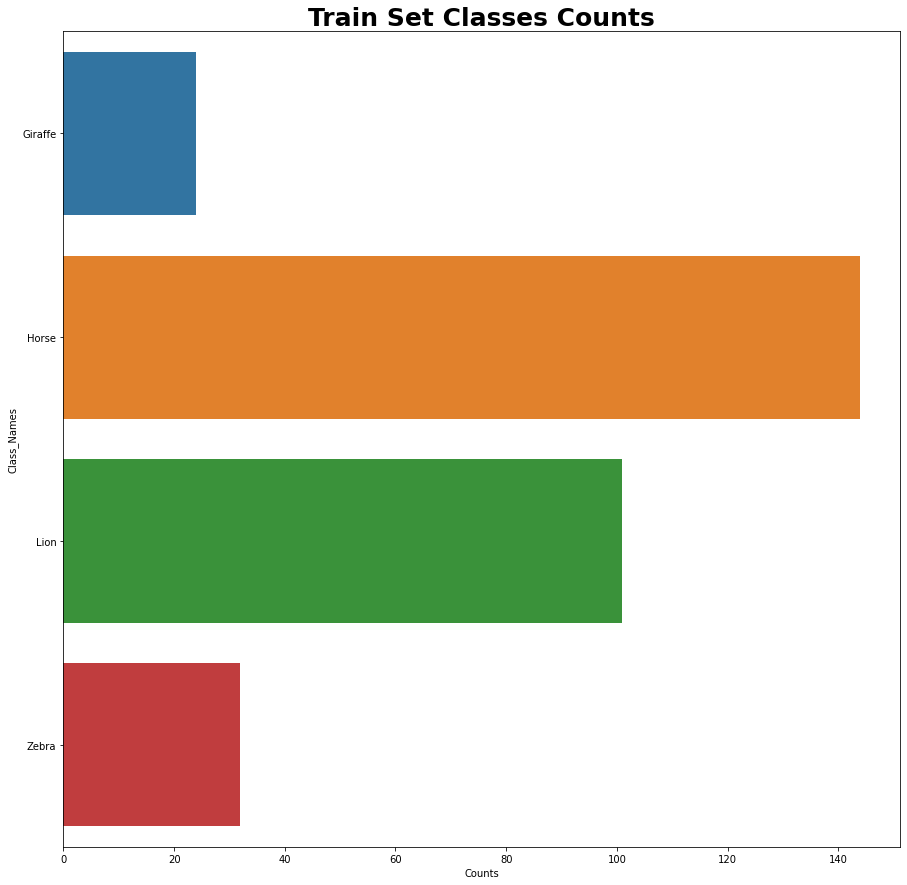

In [7]:
# A variable to store number of images in each class and class names.
counts = []

# Loop over classes
for class_name in labels :
    class_path = os.path.join(test_dir, class_name)
    count = len(os.listdir(class_path))
    counts.append((class_name, count))

# Convert variable to DataFrame
counts = pd.DataFrame(counts, columns=['Class_Names', 'Counts'])

# Plot the DataFrame
plt.figure(figsize=(15, 15))
ax = sns.barplot(data=counts, y='Class_Names', x='Counts')
ax.set_title('Train Set Classes Counts', fontsize=25, fontweight='bold')

plt.show()

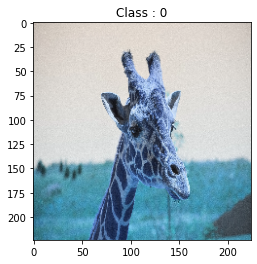

In [8]:
# Display the first 3 training images with their class labels
for i in range(1):
    plt.imshow(X[i])
    plt.title(f"Class : {Y[i]}")
    plt.show()

In [9]:
import torch
import torch.nn as nn
import torchvision.models as models

# Load pre-trained ResNet50
base_model = models.resnet50(pretrained=True)

# Remove the final fully connected layer to mimic include_top=False
# This creates a feature extractor that outputs a (batch, 2048, 1, 1) feature map (if using global avg pooling)
base_model = nn.Sequential(*list(base_model.children())[:-1])

# Freeze all layers
for param in base_model.parameters():
    param.requires_grad = False


In [10]:
import torch
import torch.nn as nn
import torchvision.models as models

# Automatically set device to GPU if available, else CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print('Training on device =', device)

class AnimalClassifier(nn.Module):
    def __init__(self, num_classes: int):
        super(AnimalClassifier, self).__init__()
        # Load a pre-trained ResNet50 model
        resnet = models.resnet50(pretrained=True)
        # Remove the final fully-connected layer (i.e. include_top=False)
        self.features = nn.Sequential(*list(resnet.children())[:-1])
        
        # Freeze the ResNet50 feature extractor parameters
        for param in self.features.parameters():
            param.requires_grad = False
        
        # Define the classification head with BatchNorm and Dropout
        self.flatten = nn.Flatten()  # Flatten layer
        self.fc1 = nn.Linear(2048, 1024)
        self.bn1 = nn.BatchNorm1d(1024)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(p=0.5)
        
        self.fc2 = nn.Linear(1024, 512)
        self.bn2 = nn.BatchNorm1d(512)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(p=0.5)
        
        self.fc3 = nn.Linear(512, num_classes)
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)        # Expected output shape: (batch, 2048, 1, 1)
        x = x.view(x.size(0), -1)     # Flatten to (batch, 2048)
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.dropout1(x)
        x = self.fc2(x)
        x = self.bn2(x)
        x = self.relu2(x)
        x = self.dropout2(x)
        x = self.fc3(x)
        return x

# Load chosen labels from configuration (assume you have a config loader)
config = load_config('config.json')
labels = config.get('labels', [])
num_classes = len(labels)

model = AnimalClassifier(num_classes=num_classes)
model.to(device)


Training on device = cuda


AnimalClassifier(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): C

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Convert the training and validation data to PyTorch tensors.
# Also, convert images from HWC to CHW format and normalize them (scaling pixel values between 0 and 1)
X_train_tensor = torch.tensor(X, dtype=torch.float32).permute(0, 3, 1, 2) / 255.0
Y_train_tensor = torch.tensor(Y, dtype=torch.long)

X_valid_tensor = torch.tensor(X_valid, dtype=torch.float32).permute(0, 3, 1, 2) / 255.0
Y_valid_tensor = torch.tensor(Y_valid, dtype=torch.long)

# Create TensorDatasets and DataLoaders
batch_size = 2
train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)
valid_dataset = TensorDataset(X_valid_tensor, Y_valid_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)

In [12]:
import random
import numpy as np
import torch

def set_seed(seed: int) -> None:
    """
    Sets the random seed for Python's random module, NumPy, and PyTorch to ensure reproducibility.
    
    :param seed: The seed value to use.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # if using multi-GPU.
    # Ensure deterministic behavior in cudnn (may slow down performance)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Set the seed
set_seed(0)

In [13]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import torch

class AnimalDataset(Dataset):
    def __init__(self, images: np.ndarray, labels: np.ndarray, transform: transforms.Compose = None):
        """
        Custom dataset for animal images.
        
        :param images: NumPy array of images with shape (N, H, W, C)
        :param labels: NumPy array of labels
        :param transform: torchvision transforms to apply to each image
        """
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self) -> int:
        return len(self.images)

    def __getitem__(self, idx: int):
        # Convert the NumPy image to a PIL Image
        img = Image.fromarray(self.images[idx].astype('uint8'))
        label = int(self.labels[idx])
        if self.transform:
            img = self.transform(img)
        else:
            # Default conversion: ToTensor scales pixel values to [0, 1]
            img = transforms.ToTensor()(img)
        return img, label

# Define training transforms including augmentation
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Define validation transforms (only resize and normalization)
valid_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Suppose you already loaded your NumPy arrays for training and validation: X_train, Y_train, X_valid, Y_valid
train_dataset = AnimalDataset(X, Y, transform=train_transforms)
valid_dataset = AnimalDataset(X_valid, Y_valid, transform=valid_transforms)

batch_size = 4
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)


In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import f1_score, precision_score, recall_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Set up the optimizer and loss criterion
optimizer = optim.Adam(model.parameters(), lr=0.001)
weights = torch.tensor([1.0, 1.0, 1.5, 1.7]).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)

num_epochs = 100

for epoch in range(num_epochs):
    # Training phase
    model.train()
    running_loss = 0.0
    running_corrects = 0
    train_preds = []
    train_labels = []
    
    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)  # Forward pass
        loss = criterion(outputs, labels)
        loss.backward()          # Backpropagation
        optimizer.step()         # Update weights
        
        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        running_corrects += torch.sum(preds == labels.data)
        
        # Collect predictions and true labels
        train_preds.extend(preds.cpu().numpy())
        train_labels.extend(labels.cpu().numpy())
    
    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = running_corrects.double() / len(train_dataset)
    
    # Compute additional metrics on the training set using macro averaging
    train_f1 = f1_score(train_labels, train_preds, average='macro')
    train_precision = precision_score(train_labels, train_preds, average='macro')
    train_recall = recall_score(train_labels, train_preds, average='macro')
    
    # Validation phase
    model.eval()
    val_loss = 0.0
    val_corrects = 0
    val_preds = []
    val_labels = []
    
    with torch.no_grad():
        for inputs, labels in valid_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            val_corrects += torch.sum(preds == labels.data)
            
            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())
    
    val_loss = val_loss / len(valid_dataset)
    val_acc = val_corrects.double() / len(valid_dataset)
    
    # Compute additional metrics on the validation set using macro averaging
    val_f1 = f1_score(val_labels, val_preds, average='macro')
    val_precision = precision_score(val_labels, val_preds, average='macro')
    val_recall = recall_score(val_labels, val_preds, average='macro')
    
    # Print all metrics for the epoch
    print(f"Epoch {epoch+1}/{num_epochs} - "
          f"loss: {epoch_loss:.4f} - accuracy: {epoch_acc:.4f} - "
          f"train_f1 (macro): {train_f1:.4f} - train_precision (macro): {train_precision:.4f} - train_recall (macro): {train_recall:.4f} - "
          f"val_loss: {val_loss:.4f} - val_accuracy: {val_acc:.4f} - "
          f"val_f1 (macro): {val_f1:.4f} - val_precision (macro): {val_precision:.4f} - val_recall (macro): {val_recall:.4f}")
    
    # Save checkpoint with F1 scores in the filename
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'epoch_loss': epoch_loss,
        'val_loss': val_loss,
        'epoch_acc': epoch_acc,
        'val_acc': val_acc,
        'train_f1': train_f1,
        'val_f1': val_f1,
    }
    
    num_classes = 4
    PATH = f"checkpoints/checkpoint_{epoch}epoch_{train_f1:.4f}trainF1_{val_f1:.4f}valF1_{num_classes}c.pth"
    torch.save(checkpoint, PATH)
    print(f"Checkpoint saved to {PATH}")

Epoch 1/100 - loss: 0.2939 - accuracy: 0.9045 - train_f1 (macro): 0.9097 - train_precision (macro): 0.9086 - train_recall (macro): 0.9109 - val_loss: 0.2514 - val_accuracy: 0.9226 - val_f1 (macro): 0.8870 - val_precision (macro): 0.8636 - val_recall (macro): 0.9345
Checkpoint saved to checkpoints/checkpoint_0epoch_0.9097trainF1_0.8870valF1_4c.pth
Epoch 2/100 - loss: 0.3055 - accuracy: 0.9018 - train_f1 (macro): 0.9049 - train_precision (macro): 0.9041 - train_recall (macro): 0.9059 - val_loss: 0.1857 - val_accuracy: 0.9529 - val_f1 (macro): 0.9204 - val_precision (macro): 0.9011 - val_recall (macro): 0.9510
Checkpoint saved to checkpoints/checkpoint_1epoch_0.9049trainF1_0.9204valF1_4c.pth
Epoch 3/100 - loss: 0.3039 - accuracy: 0.9025 - train_f1 (macro): 0.9067 - train_precision (macro): 0.9065 - train_recall (macro): 0.9071 - val_loss: 0.2637 - val_accuracy: 0.9125 - val_f1 (macro): 0.8653 - val_precision (macro): 0.8317 - val_recall (macro): 0.9209
Checkpoint saved to checkpoints/chec

In [15]:
import re
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def parse_log_and_plot(log_text: str) -> None:

    # Define regex pattern to extract metrics from lines starting with "Epoch"
    pattern = re.compile(
        r"Epoch\s+(\d+)/\d+\s+-\s+loss:\s+([\d.]+)\s+-\s+accuracy:\s+([\d.]+)\s+-\s+val_loss:\s+([\d.]+)\s+-\s+val_accuracy:\s+([\d.]+)"
    )
    
    epochs, train_losses, train_accs, val_losses, val_accs = [], [], [], [], []
    
    for line in log_text.splitlines():
        match = pattern.search(line)
        if match:
            epochs.append(int(match.group(1)))
            train_losses.append(float(match.group(2)))
            train_accs.append(float(match.group(3)))
            val_losses.append(float(match.group(4)))
            val_accs.append(float(match.group(5)))
    
    # Create DataFrames for plotting
    df_loss = pd.DataFrame({
        "Epoch": epochs,
        "Training Loss": train_losses,
        "Validation Loss": val_losses
    })
    df_acc = pd.DataFrame({
        "Epoch": epochs,
        "Training Accuracy": train_accs,
        "Validation Accuracy": val_accs
    })
    
    # Identify the best validation accuracy (the "sweet spot")
    best_idx = df_acc["Validation Accuracy"].idxmax()
    best_idx = 38
    best_epoch = df_acc.loc[best_idx, "Epoch"]
    best_train_acc = df_acc.loc[best_idx, "Training Accuracy"]
    best_val_acc = df_acc.loc[best_idx, "Validation Accuracy"]
    
    # Set up Seaborn style and define a darker pink-blue palette
    sns.set(style="whitegrid", context="talk")
    dark_pink_blue_palette = sns.color_palette(["#C2185B", "#303F9F"])
    
    # Melt the data for plotting
    loss_melted = df_loss.melt("Epoch", var_name="Metric", value_name="Loss")
    acc_melted = df_acc.melt("Epoch", var_name="Metric", value_name="Accuracy")
    
    # Create subplots: one for loss, one for accuracy
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    
    # Plot Loss
    sns.lineplot(ax=axes[0], data=loss_melted, x="Epoch", y="Loss", hue="Metric", marker="o", palette=dark_pink_blue_palette)
    axes[0].set_title("Training vs Validation Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    
    # Plot Accuracy
    sns.lineplot(ax=axes[1], data=acc_melted, x="Epoch", y="Accuracy", hue="Metric", marker="o", palette=dark_pink_blue_palette)
    axes[1].set_title("Training vs Validation Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    
        # Mark and annotate the best validation accuracy ("sweet spot")
    axes[0].axvline(x=best_epoch, color="gray", linestyle="--", linewidth=1)
    axes[0].annotate(
        f"Good Model",
        xy=(best_epoch, best_val_acc),
        xytext=(best_epoch + 1, best_val_acc - 0.05),
        arrowprops=dict(facecolor="black", arrowstyle="->"),
        fontsize=12,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=1)
    )
    # Mark and annotate the best validation accuracy ("sweet spot")
    axes[1].axvline(x=best_epoch, color="gray", linestyle="--", linewidth=1)
    axes[1].annotate(
        f"Good Model\nVal Accuracy: {best_val_acc:.4f}\nTrain Accuracy: {best_train_acc:.4f}\n(Epoch {best_epoch})",
        xy=(best_epoch, best_val_acc),
        xytext=(best_epoch + 1, best_val_acc - 0.05),
        arrowprops=dict(facecolor="black", arrowstyle="->"),
        fontsize=12,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=1)
    )
    
    
    #plt.tight_layout()
    plt.show()

# Example usage:
log_text = '''
'''
parse_log_and_plot(log_text)


ValueError: attempt to get argmax of an empty sequence

In [19]:
import torch

# --- Saving Checkpoint ---
# Assume these variables are defined during training:
# epoch, model, optimizer, loss, etc.
checkpoint = {
    'epoch': epoch,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'epoch_loss': epoch_loss,
    'val_loss': val_loss,
    'epoch_acc': epoch_acc,
    'val_acc': val_acc,
    # ... any additional keys you wish to save
}

SAVE_PATH = f"checkpoints/checkpoint_{epoch}epoch.pth"
#torch.save(checkpoint, PATH)
print(f"Checkpoint saved to {PATH}")

# --- Loading Checkpoint ---
# Determine the device to load the model to (GPU if available, else CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Loading checkpoint on device:", device)

# If you want to load only the weights, use map_location
LOAD_PATH = f"checkpoints/checkpoint_99epoch_0.9023trainF1_0.8794valF1_4c.pth"
checkpoint = torch.load(LOAD_PATH, map_location=device)

labels = os.listdir(train_dir)
num_classes = len(labels)
num_classes =4

# Create your model and optimizer (using your model class and optimizer class)
model = AnimalClassifier(num_classes=num_classes)    
model.load_state_dict(checkpoint['model_state_dict'])      
optimizer = optim.Adam(model.parameters(), lr=0.001)
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

# Load the state dictionaries
epoch = checkpoint['epoch']
epoch_loss = checkpoint['epoch_loss']
val_loss = checkpoint['val_loss']
epoch_acc = checkpoint['epoch_acc']
val_acc = checkpoint['val_acc']

# Move model to the device and set mode
model.to(device)
optimizer.zero_grad()
model.train()  # or model.train() if continuing training

print(f"Checkpoint loaded: epoch={epoch}, loss={epoch_loss:.4f}")


Checkpoint saved to checkpoints/checkpoint_99epoch_0.9023trainF1_0.8794valF1_4c.pth
Loading checkpoint on device: cuda
Checkpoint loaded: epoch=99, loss=0.3059


Score de précision: 0.8722590515043345


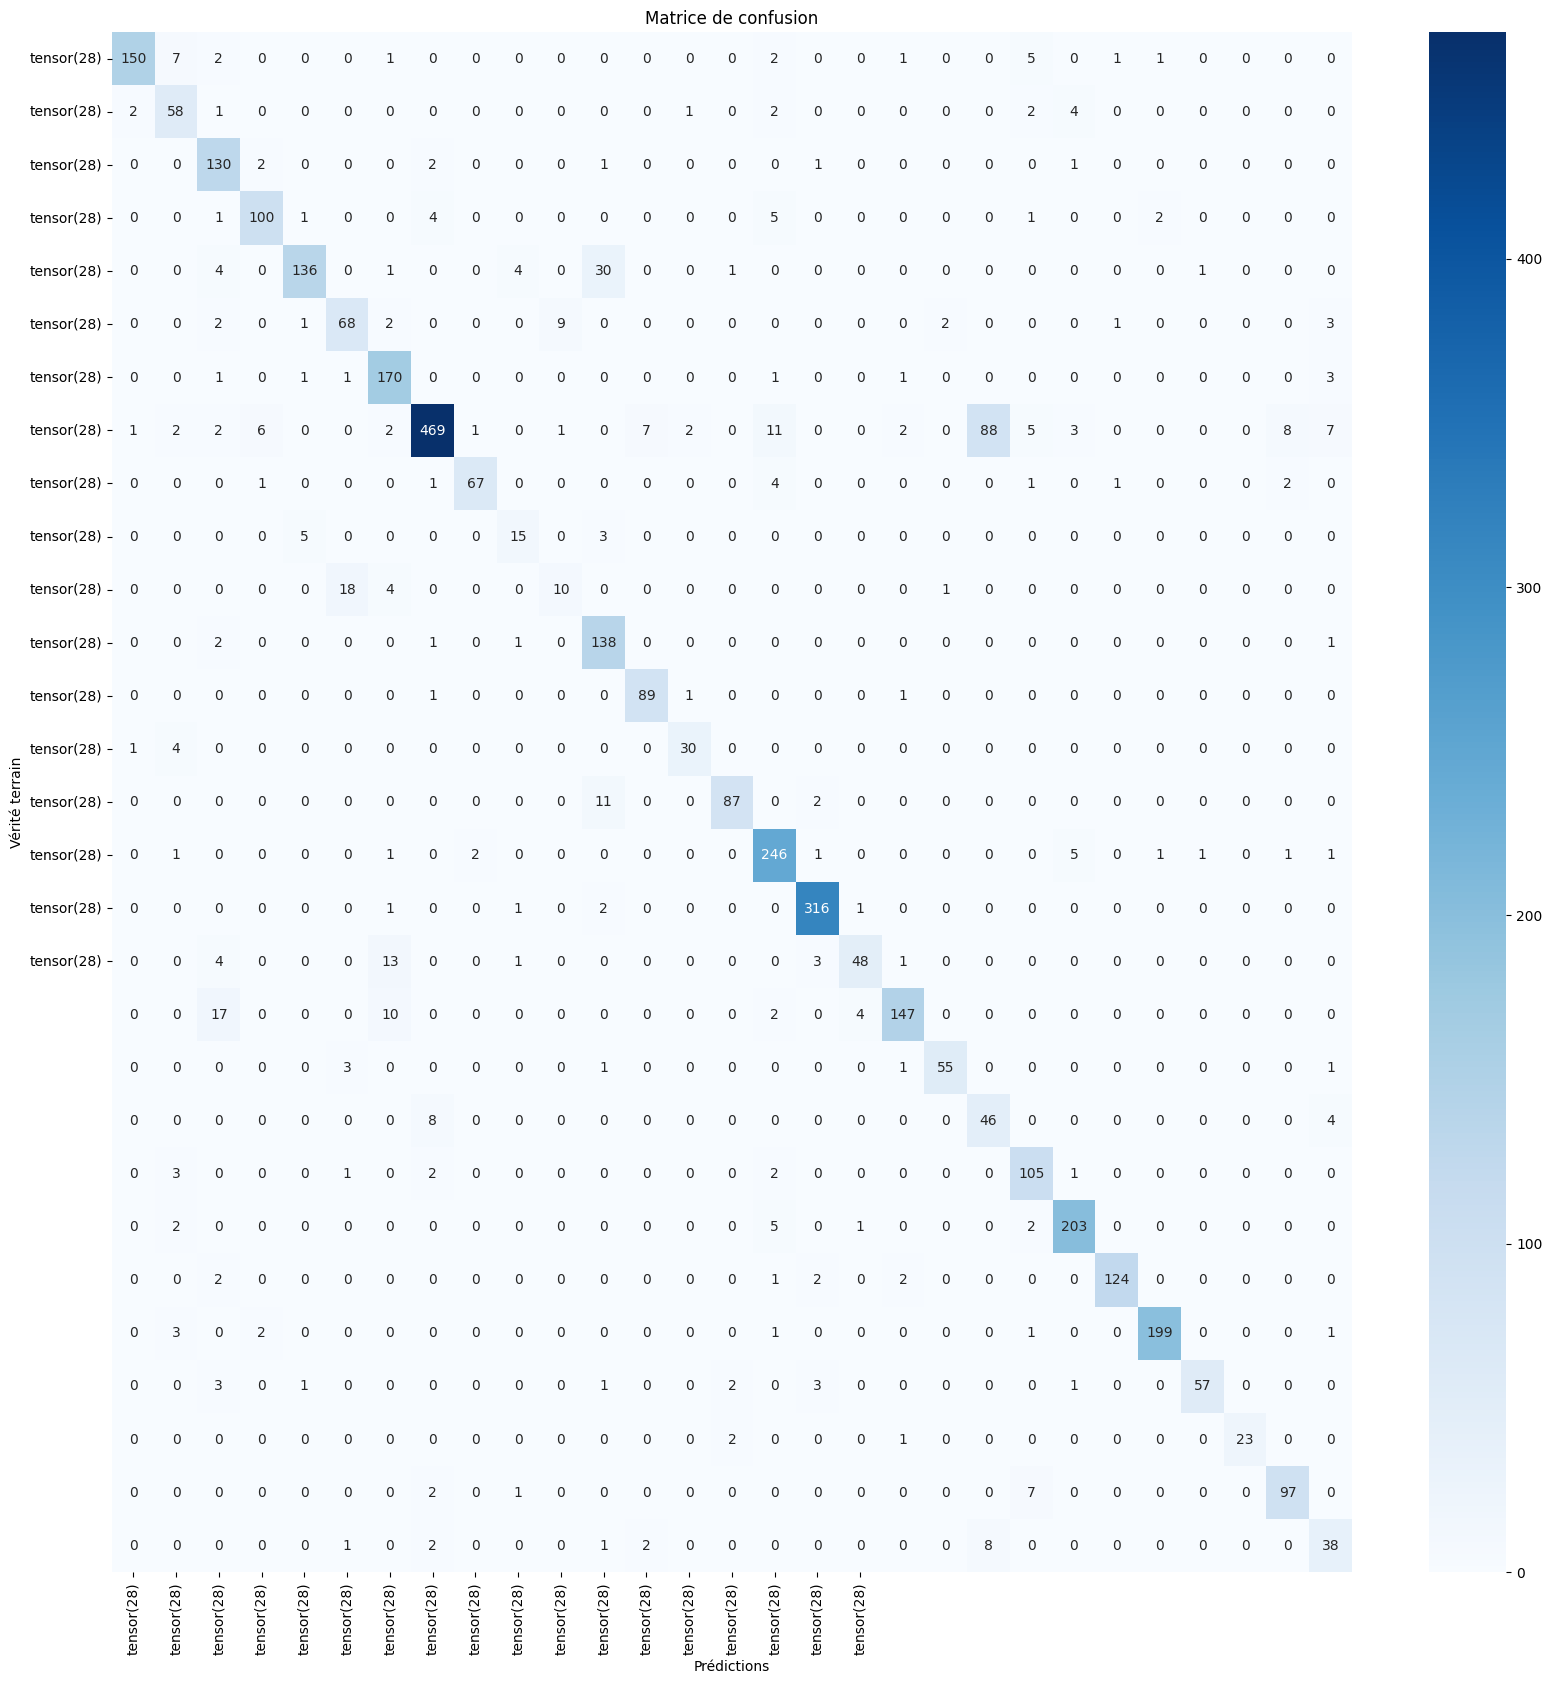

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# --- Model Evaluation on Validation Data ---
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for inputs, batch_labels in valid_loader:  # Renamed from 'labels' to 'batch_labels'
        outputs = model(inputs)  # outputs are logits
        _, preds = torch.max(outputs, 1)
        all_preds.append(preds.cpu().numpy())
        all_labels.append(batch_labels.cpu().numpy())

# Concatenate all batches
Y_pred_classes = np.concatenate(all_preds)
Y_true = np.concatenate(all_labels)

# Compute confusion matrix and accuracy
conf_matrix = confusion_matrix(Y_true, Y_pred_classes)
acc_score = accuracy_score(Y_true, Y_pred_classes)
print("Accuracy Score:", acc_score)

# Plot confusion matrix using your global "labels" list as tick labels
plt.figure(figsize=(20,20))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix')
plt.xlabel('Predictions')
plt.ylabel('Ground Truth')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# --- Plotting Training History ---
# Here, we assume you collected training history in the following lists:
# train_losses, valid_losses, train_accs, valid_accs
# For example, you could have appended epoch_loss and epoch_acc for each epoch in your training loop.

# Plot Loss History
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(valid_losses, label='Validation Loss')
plt.title('Training and Validation Loss History')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

# Plot Accuracy History
plt.figure(figsize=(10, 6))
plt.plot(train_accs, label='Training Accuracy')
plt.plot(valid_accs, label='Validation Accuracy')
plt.title('Training and Validation Accuracy History')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

# --- Classification Report ---
report = classification_report(Y_true, Y_pred_classes, target_names=labels)
print(report)


In [ ]:
import torch 
print(torch.__version__)

1.10.1+cu102
